# Niño 3.4 and Ningaloo Niño Index

Period-specific-climatology NNI. DJF(Y) is December(Y−1) through February(Y); underlying values and calculations are unchanged.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SCRIPT_DIR=Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/Ningaloo'); OUTPUT_DIR=SCRIPT_DIR/'enso_nni_period_specific_outputs'; OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
NNI_FILE=SCRIPT_DIR/'ningaloo_nino_index_DJF_period_specific_climatology_1981-2025.csv'; NINO34_FILE=Path('/Users/rizzie/ClimateData/climate_index/ENSO/nino34.anomersstv5.csv')
PNG_FILE=OUTPUT_DIR/'DJF_nino34_NNI_manuscript_period_specific.png'; STATS_FILE=OUTPUT_DIR/'DJF_nino34_NNI_statistics_period_specific.csv'

nni=pd.read_csv(NNI_FILE)[['year','period','nni_djf']].copy(); nni['year']=pd.to_numeric(nni.year,errors='raise').astype(int); nni['nni_djf']=pd.to_numeric(nni.nni_djf,errors='coerce')
raw=pd.read_csv(NINO34_FILE).iloc[:,:2].copy(); raw.columns=['date','nino34']; raw['date']=pd.to_datetime(raw.date,errors='coerce'); raw['nino34']=pd.to_numeric(raw.nino34,errors='coerce'); raw.loc[raw.nino34.abs()>100,'nino34']=np.nan
monthly=raw.dropna(subset=['date']).set_index('date').nino34.sort_index()

def djf_mean(year):
    values=monthly.reindex(pd.to_datetime([f'{year-1}-12-01',f'{year}-01-01',f'{year}-02-01']))
    return values.mean() if values.notna().all() else np.nan

nino=pd.DataFrame({'year':range(1981,2026)}); nino['nino34_djf']=[djf_mean(year) for year in nino.year]
analysis=nni.merge(nino,on='year',validate='one_to_one').sort_values('year').reset_index(drop=True)
if len(analysis)!=45 or not analysis.year.eq(range(1981,2026)).all(): raise ValueError('Expected DJF 1981–2025.')
analysis['nino34_standardized']=(analysis.nino34_djf-analysis.nino34_djf.mean())/analysis.nino34_djf.std(ddof=1)

def period_fit(period):
    data=analysis.loc[analysis.period.eq(period),['nino34_standardized','nni_djf']].dropna()
    slope,intercept,r,p,slope_se=stats.linregress(data.nino34_standardized,data.nni_djf)
    return {'period':period,'n':len(data),'r':r,'correlation_p':p,'intercept':intercept,'slope_degC_per_1sigma_nino34':slope,'slope_standard_error':slope_se,'data':data}

fits={period:period_fit(period) for period in ('P1','P2')}
statistics_table=pd.DataFrame([{k:v for k,v in fit.items() if k!='data'} for fit in fits.values()]); statistics_table.to_csv(STATS_FILE,index=False); display(statistics_table)
p1,p2=fits['P1'],fits['P2']; z=(np.arctanh(p1['r'])-np.arctanh(p2['r']))/np.sqrt(1/(p1['n']-3)+1/(p2['n']-3)); fisher_p=2*stats.norm.sf(abs(z))
model=analysis.dropna(subset=['nino34_standardized','nni_djf']); x=model.nino34_standardized.to_numpy(); group=model.period.eq('P2').astype(int).to_numpy(); y=model.nni_djf.to_numpy(); X=np.column_stack([np.ones(len(model)),x,group,x*group]); coef=np.linalg.lstsq(X,y,rcond=None)[0]; res=y-X@coef; df=len(y)-4; slope_difference=coef[3]; se=np.sqrt((res@res/df)*np.linalg.inv(X.T@X)[3,3]); slope_difference_p=2*stats.t.sf(abs(slope_difference/se),df)
print(f'Correlation difference (P1 − P2): Δr = {p1["r"]-p2["r"]:.3f}; Fisher z = {z:.3f}; p = {fisher_p:.3f}')
print(f'Slope difference (P2 − P1): Δβ = {slope_difference:.3f} °C per 1σ Niño 3.4; interaction p = {slope_difference_p:.3f}')


,period,n,r,correlation_p,intercept,slope_degC_per_1sigma_nino34,slope_standard_error
0,P1,26,-0.295680,0.142498,-0.001704,-0.183894,0.121276
1,P2,19,-0.499354,0.029501,-0.015642,-0.298186,0.125479


Correlation difference (P1 − P2): Δr = 0.204; Fisher z = 0.748; p = 0.454
Slope difference (P2 − P1): Δβ = -0.114 °C per 1σ Niño 3.4; interaction p = 0.522


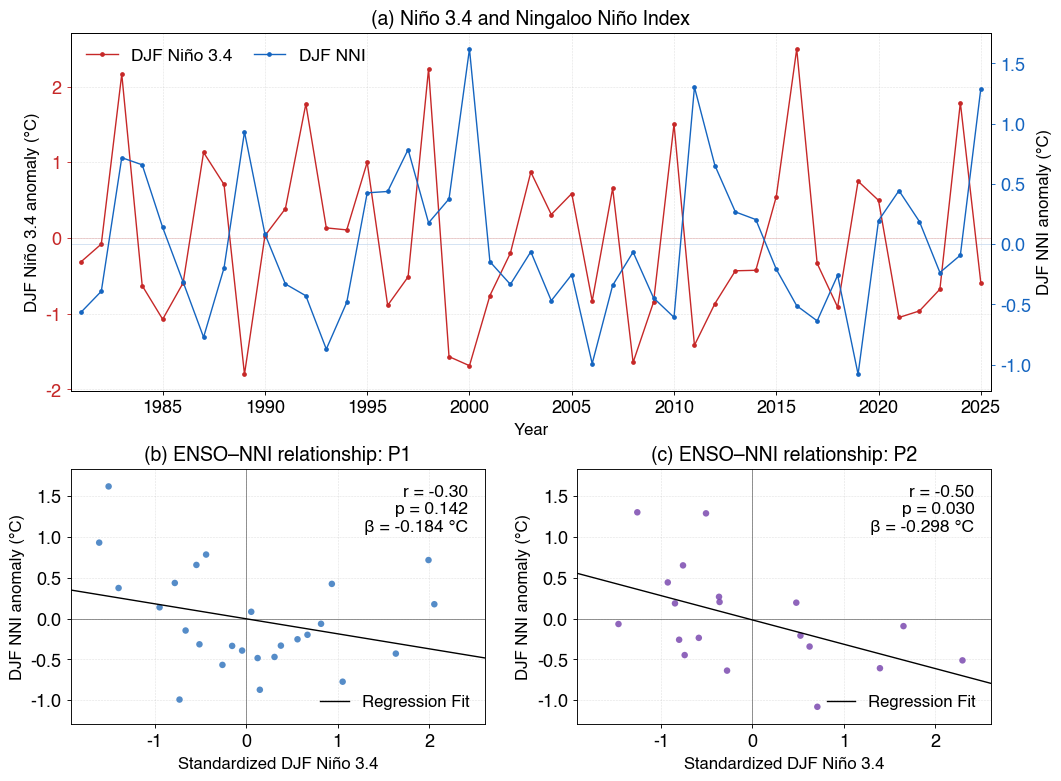

Saved PNG: /Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/Ningaloo/enso_nni_period_specific_outputs/DJF_nino34_NNI_manuscript_period_specific.png


In [2]:
COLORS={'nino':'#c62828','nni':'#1565c0','P1':'#3778bf','P2':'#7b4ab0'}
plt.rcParams.update({'font.family':'sans-serif','font.sans-serif':['Helvetica','Arial','DejaVu Sans'],'font.size':14,'axes.labelsize':12,'axes.titlesize':14,'xtick.labelsize':13,'ytick.labelsize':13,'legend.fontsize':12.5,'axes.linewidth':.65,'axes.unicode_minus':False})
fig=plt.figure(figsize=(10.5,7.7),constrained_layout=True); grid=fig.add_gridspec(2,2,height_ratios=(1.4,1.0))
ax_time=fig.add_subplot(grid[0,:]); ax_nni=ax_time.twinx()
nino_line=ax_time.plot(analysis.year,analysis.nino34_djf,color=COLORS['nino'],marker='o',ms=2.4,lw=1.0,label='DJF Niño 3.4'); nni_line=ax_nni.plot(analysis.year,analysis.nni_djf,color=COLORS['nni'],marker='o',ms=2.4,lw=1.0,label='DJF NNI')
ax_time.axhline(0,color=COLORS['nino'],lw=.45,alpha=.28); ax_nni.axhline(0,color=COLORS['nni'],lw=.45,alpha=.28)
ax_time.set(xlim=(1980.5,2025.5),xlabel='Year',ylabel='DJF Niño 3.4 anomaly (°C)',title='(a) Niño 3.4 and Ningaloo Niño Index'); ax_nni.set_ylabel('DJF NNI anomaly (°C)')
ax_time.tick_params(axis='y',colors=COLORS['nino'],width=.65,length=3); ax_nni.tick_params(axis='y',colors=COLORS['nni'],width=.65,length=3); ax_time.tick_params(axis='x',width=.65,length=3)
for axis in (ax_time,ax_nni):
    for spine in axis.spines.values(): spine.set_linewidth(.65)
ax_time.grid(True,linestyle='--',linewidth=.4,alpha=.32,color='0.65'); ax_time.set_axisbelow(True); ax_time.legend(nino_line+nni_line,[line.get_label() for line in nino_line+nni_line],loc='upper left',frameon=False,ncol=2,handlelength=1.8,columnspacing=1.2)

scatter=pd.concat([fit['data'] for fit in fits.values()]); xr,yr=np.ptp(scatter.nino34_standardized),np.ptp(scatter.nni_djf); x_limits=(scatter.nino34_standardized.min()-.08*xr,scatter.nino34_standardized.max()+.08*xr); y_limits=(scatter.nni_djf.min()-.08*yr,scatter.nni_djf.max()+.08*yr)
for axis,period,title in zip((fig.add_subplot(grid[1,0]),fig.add_subplot(grid[1,1])),('P1','P2'),('(b) ENSO–NNI relationship: P1','(c) ENSO–NNI relationship: P2')):
    fit,data=fits[period],fits[period]['data']; x,y=data.nino34_standardized.to_numpy(),data.nni_djf.to_numpy(); x_line=np.linspace(*x_limits,250); y_line=fit['intercept']+fit['slope_degC_per_1sigma_nino34']*x_line
    axis.scatter(x,y,color=COLORS[period],s=22,alpha=.85,edgecolor='none',zorder=3); axis.plot(x_line,y_line,color='black',lw=1.0,label='Regression Fit',zorder=4)
    axis.axhline(0,color='0.40',lw=.5); axis.axvline(0,color='0.40',lw=.5); axis.set(xlim=x_limits,ylim=y_limits,xlabel='Standardized DJF Niño 3.4',ylabel='DJF NNI anomaly (°C)',title=title)
    axis.grid(True,linestyle='--',linewidth=.4,alpha=.32,color='0.65'); axis.set_axisbelow(True); axis.tick_params(width=.65,length=3)
    for spine in axis.spines.values(): spine.set_linewidth(.65)
    axis.text(.96,.94,f"r = {fit['r']:.2f}\np = {fit['correlation_p']:.3f}\nβ = {fit['slope_degC_per_1sigma_nino34']:.3f} °C",transform=axis.transAxes,ha='right',va='top',fontsize=12.5,fontweight='normal')
    axis.legend(loc='lower right',frameon=False,fontsize=12,handlelength=1.7)
fig.savefig(PNG_FILE,dpi=300,bbox_inches='tight'); plt.show(); print(f'Saved PNG: {PNG_FILE}')
